In [1]:
import numpy as np
import pandas as pd
import xarray as xr

ds = xr.open_dataset("merged_32x32.nc")
pre_data = np.load("preci_32.npz", allow_pickle=True)
X_pre = pre_data["X"]
time_pre = pd.to_datetime(pre_data["time"])

lat_slice = slice(0, 10)
lon_slice = slice(8, 16)

chl_da = ds["chl"].isel(latitude=lat_slice, longitude=lon_slice)
chl_sel = chl_da.sel(time=time_pre)
chl_box = chl_sel.mean(dim=("latitude", "longitude")).values

prec_box = np.nanmean(X_pre[:, lat_slice, lon_slice, 0], axis=(1, 2))

df = pd.DataFrame({"time": time_pre, "chl": chl_box, "prec": prec_box})
df = df.set_index("time").sort_index()
df["prec_14d"] = df["prec"].rolling(14, min_periods=1).sum()
df["month"] = df.index.month

vars_ocean = ["thetao", "so", "no3", "po4", "si", "o2", "nppv"]
for v in vars_ocean:
    da_v = ds[v].isel(latitude=lat_slice, longitude=lon_slice)
    da_v_sel = da_v.sel(time=time_pre)
    df[v] = da_v_sel.mean(dim=("latitude", "longitude")).values

df["N_P_ratio"] = df["no3"] / df["po4"]
df["Si_N_ratio"] = df["si"] / df["no3"]

df_all = df.dropna()
print(df_all.head())
print(df_all.columns)


                 chl          prec  prec_14d  month     thetao         so  \
time                                                                        
2014-01-03  1.095409 -2.047970e-02 -0.020480      1  18.931520  35.914679   
2014-01-04  1.298192 -9.891389e-17 -0.020480      1  18.930375  36.047688   
2014-01-06  1.298294  4.995311e+00  4.974831      1  18.766976  35.982312   
2014-01-07  1.402788  1.615787e-03  4.976447      1  18.157670  35.890774   
2014-01-08  1.369935  8.133887e-02  5.057786      1  17.913745  35.909842   

                 no3       po4        si          o2       nppv  N_P_ratio  \
time                                                                         
2014-01-03  0.199871  0.017965  4.297507  227.235306  30.073009  11.125333   
2014-01-04  0.194015  0.012686  4.225826  228.662195  25.745980  15.294067   
2014-01-06  0.198527  0.015101  4.290098  229.623587  24.372000  13.146341   
2014-01-07  0.219318  0.012603  4.350187  230.913595  28.886179  17.40

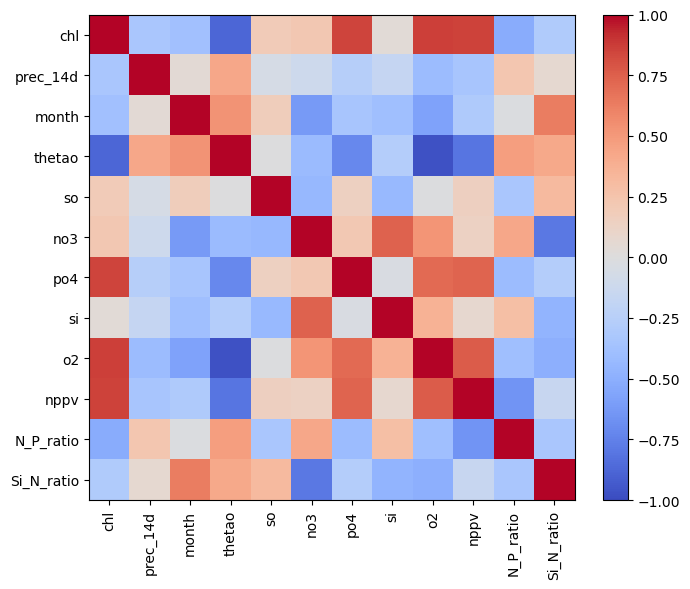

In [2]:
import matplotlib.pyplot as plt

cols_corr = ["chl", "prec_14d", "month"] + vars_ocean + ["N_P_ratio", "Si_N_ratio"]
corr = df_all[cols_corr].corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(cols_corr)), cols_corr, rotation=90)
plt.yticks(range(len(cols_corr)), cols_corr)
plt.tight_layout()
plt.show()


In [3]:
import statsmodels.api as sm

features_core = ["prec_14d", "month", "po4", "nppv", "o2"]
X_core = df_all[features_core]
y_core = df_all["chl"]

Xc_sm = sm.add_constant(X_core)
model_core = sm.OLS(y_core, Xc_sm).fit()
print(model_core.summary())


                            OLS Regression Results                            
Dep. Variable:                    chl   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     5907.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        02:06:36   Log-Likelihood:                 3123.5
No. Observations:                3216   AIC:                            -6235.
Df Residuals:                    3210   BIC:                            -6198.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1187      0.052    -40.875      0.0

In [4]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset("merged_32x32.nc")
pre_data = np.load("preci_32.npz", allow_pickle=True)
time_pre = pd.to_datetime(pre_data["time"])

lat_slice = slice(0, 10)
lon_near = slice(0, 6)
lon_mid = slice(6, 12)
lon_off = slice(12, 18)

chl_near = ds["chl"].isel(latitude=lat_slice, longitude=lon_near).sel(time=time_pre).mean(dim=("latitude", "longitude")).values
chl_mid = ds["chl"].isel(latitude=lat_slice, longitude=lon_mid).sel(time=time_pre).mean(dim=("latitude", "longitude")).values
chl_off = ds["chl"].isel(latitude=lat_slice, longitude=lon_off).sel(time=time_pre).mean(dim=("latitude", "longitude")).values

df_box = pd.DataFrame(
    {
        "time": time_pre,
        "chl_near": chl_near,
        "chl_mid": chl_mid,
        "chl_off": chl_off,
    }
).set_index("time").dropna()


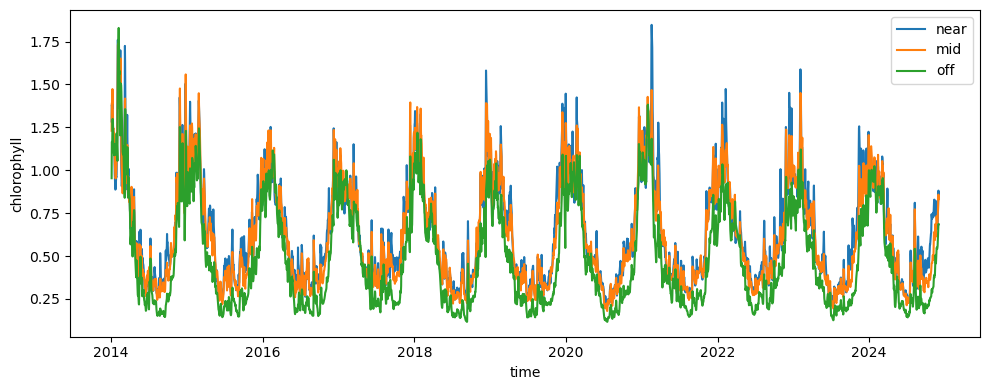

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(df_box.index, df_box["chl_near"], label="near")
plt.plot(df_box.index, df_box["chl_mid"], label="mid")
plt.plot(df_box.index, df_box["chl_off"], label="off")
plt.xlabel("time")
plt.ylabel("chlorophyll")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
import numpy as np
import pandas as pd
import xarray as xr

ds = xr.open_dataset("merged_32x32.nc")
pre_data = np.load("preci_32.npz", allow_pickle=True)
time_pre = pd.to_datetime(pre_data["time"])

lat_slice = slice(0, 10)
lon_near = slice(0, 6)
lon_mid = slice(6, 12)
lon_off = slice(12, 18)

chl_near = ds["chl"].isel(latitude=lat_slice, longitude=lon_near).sel(time=time_pre).mean(dim=("latitude", "longitude")).values
chl_mid = ds["chl"].isel(latitude=lat_slice, longitude=lon_mid).sel(time=time_pre).mean(dim=("latitude", "longitude")).values
chl_off = ds["chl"].isel(latitude=lat_slice, longitude=lon_off).sel(time=time_pre).mean(dim=("latitude", "longitude")).values

df_box = pd.DataFrame(
    {
        "time": time_pre,
        "chl_near": chl_near,
        "chl_mid": chl_mid,
        "chl_off": chl_off,
    }
).set_index("time").dropna()

mean_near = df_box["chl_near"].mean()
mean_mid = df_box["chl_mid"].mean()
mean_off = df_box["chl_off"].mean()
print(mean_near, mean_mid, mean_off)


0.6225687626432854 0.6039705106573146 0.4683931503861854


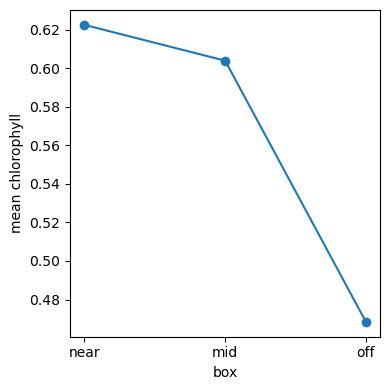

In [7]:
import numpy as np
import matplotlib.pyplot as plt

vals = [mean_near, mean_mid, mean_off]
x = np.arange(3)

plt.figure(figsize=(4, 4))
plt.plot(x, vals, marker="o")
plt.xticks(x, ["near", "mid", "off"])
plt.xlabel("box")
plt.ylabel("mean chlorophyll")
plt.tight_layout()
plt.show()


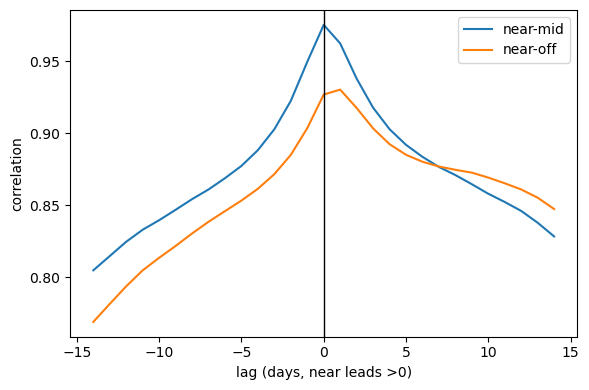

In [8]:
def lag_corr(a, b, max_lag):
    a = a - np.nanmean(a)
    b = b - np.nanmean(b)
    lags = np.arange(-max_lag, max_lag + 1)
    corrs = []
    for k in lags:
        if k < 0:
            x = a[-k:]
            y = b[:k]
        elif k > 0:
            x = a[:-k]
            y = b[k:]
        else:
            x = a
            y = b
        c = np.corrcoef(x, y)[0, 1]
        corrs.append(c)
    return lags, np.array(corrs)

max_lag = 14
lags_nm, corr_nm = lag_corr(df_box["chl_near"].values, df_box["chl_mid"].values, max_lag)
lags_no, corr_no = lag_corr(df_box["chl_near"].values, df_box["chl_off"].values, max_lag)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(lags_nm, corr_nm, label="near-mid")
plt.plot(lags_no, corr_no, label="near-off")
plt.axvline(0, color="k", linewidth=1)
plt.xlabel("lag (days, near leads >0)")
plt.ylabel("correlation")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
import numpy as np
import pandas as pd
import xarray as xr

ds = xr.open_dataset("merged_32x32.nc")
pre_data = np.load("preci_32.npz", allow_pickle=True)
X_pre = pre_data["X"]
time_pre = pd.to_datetime(pre_data["time"])

lat_slice = slice(0, 10)
lon_slice = slice(8, 16)

chl_da = ds["chl"].isel(latitude=lat_slice, longitude=lon_slice)
chl_sel = chl_da.sel(time=time_pre)
chl_box = chl_sel.mean(dim=("latitude", "longitude")).values

prec_box = np.nanmean(X_pre[:, lat_slice, lon_slice, 0], axis=(1, 2))

df = pd.DataFrame({"time": time_pre, "chl": chl_box, "prec": prec_box})
df = df.set_index("time").sort_index()
df["prec_14d"] = df["prec"].rolling(14, min_periods=1).sum()
df["month"] = df.index.month

vars_ocean = ["thetao", "so", "no3", "po4", "si", "o2", "nppv"]
for v in vars_ocean:
    da_v = ds[v].isel(latitude=lat_slice, longitude=lon_slice)
    da_v_sel = da_v.sel(time=time_pre)
    df[v] = da_v_sel.mean(dim=("latitude", "longitude")).values

df["N_P_ratio"] = df["no3"] / df["po4"]
df["Si_N_ratio"] = df["si"] / df["no3"]

df_all = df.dropna()

lat_slice_box = slice(0, 10)
lon_near = slice(0, 6)
lon_mid = slice(6, 12)
lon_off = slice(12, 18)

chl_near = ds["chl"].isel(latitude=lat_slice_box, longitude=lon_near).sel(time=time_pre).mean(dim=("latitude", "longitude")).values
chl_mid = ds["chl"].isel(latitude=lat_slice_box, longitude=lon_mid).sel(time=time_pre).mean(dim=("latitude", "longitude")).values
chl_off = ds["chl"].isel(latitude=lat_slice_box, longitude=lon_off).sel(time=time_pre).mean(dim=("latitude", "longitude")).values

df_box = pd.DataFrame(
    {
        "time": time_pre,
        "chl_near": chl_near,
        "chl_mid": chl_mid,
        "chl_off": chl_off,
    }
).set_index("time").dropna()

df_spatial = df_all.copy()
df_spatial["chl_mid"] = df_box["chl_mid"].reindex(df_spatial.index)
df_spatial["chl_off"] = df_box["chl_off"].reindex(df_spatial.index)
df_spatial["chl_mid_lag1"] = df_spatial["chl_mid"].shift(1)
df_spatial["chl_mid_lag2"] = df_spatial["chl_mid"].shift(2)
df_spatial["chl_off_lag1"] = df_spatial["chl_off"].shift(1)
df_spatial["chl_off_lag2"] = df_spatial["chl_off"].shift(2)
df_spatial = df_spatial.dropna()

print(df_spatial.head())
print(df_spatial.columns)


                 chl          prec  prec_14d  month     thetao         so  \
time                                                                        
2014-01-06  1.298294  4.995311e+00  4.974831      1  18.766976  35.982312   
2014-01-07  1.402788  1.615787e-03  4.976447      1  18.157670  35.890774   
2014-01-08  1.369935  8.133887e-02  5.057786      1  17.913745  35.909842   
2014-01-09  1.299244 -2.181430e-16  5.057786      1  17.932361  35.929640   
2014-01-10  1.237940 -2.047400e-01  4.853046      1  18.005699  35.944416   

                 no3       po4        si          o2       nppv  N_P_ratio  \
time                                                                         
2014-01-06  0.198527  0.015101  4.290098  229.623587  24.372000  13.146341   
2014-01-07  0.219318  0.012603  4.350187  230.913595  28.886179  17.401954   
2014-01-08  0.224092  0.010634  4.361202  231.501575  25.187026  21.072537   
2014-01-09  0.212770  0.009596  4.357762  231.487830  24.361796  22.17

In [10]:
import numpy as np
import pandas as pd

feature_cols_local = [
    "prec_14d",
    "month",
    "thetao",
    "so",
    "no3",
    "po4",
    "si",
    "o2",
    "nppv",
    "N_P_ratio",
    "Si_N_ratio",
]

X_all_local_df = df_spatial[feature_cols_local].copy()
y_all_df = df_spatial[["chl"]].copy()

n = len(df_spatial)
train_size = int(n * 0.8)

X_train_local_df = X_all_local_df.iloc[:train_size]
X_test_local_df = X_all_local_df.iloc[train_size:]
y_train_df = y_all_df.iloc[:train_size]
y_test_df = y_all_df.iloc[train_size:]

mean_local = X_train_local_df.mean()
std_local = X_train_local_df.std()

X_train_local_df = (X_train_local_df - mean_local) / std_local
X_test_local_df = (X_test_local_df - mean_local) / std_local

X_train_local = X_train_local_df.to_numpy()
X_test_local = X_test_local_df.to_numpy()
y_train = y_train_df.to_numpy().ravel()
y_test = y_test_df.to_numpy().ravel()

print(X_train_local.shape, X_test_local.shape)


(2571, 11) (643, 11)


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_local = RandomForestRegressor(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features=None,
    max_depth=25,
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)

rf_local.fit(X_train_local, y_train)

y_pred_train_rf_local = rf_local.predict(X_train_local)
y_pred_test_rf_local = rf_local.predict(X_test_local)

r2_train_rf_local = r2_score(y_train, y_pred_train_rf_local)
r2_test_rf_local = r2_score(y_test, y_pred_test_rf_local)
rmse_train_rf_local = np.sqrt(mean_squared_error(y_train, y_pred_train_rf_local))
rmse_test_rf_local = np.sqrt(mean_squared_error(y_test, y_pred_test_rf_local))

print("Train R2 (rf local):", r2_train_rf_local)
print("Test R2 (rf local):", r2_test_rf_local)
print("Train RMSE (rf local):", rmse_train_rf_local)
print("Test RMSE (rf local):", rmse_test_rf_local)


Train R2 (rf local): 0.9848752030000013
Test R2 (rf local): 0.935823926338998
Train RMSE (rf local): 0.036726033523487626
Test RMSE (rf local): 0.06698929283147018


po4 0.8515835341547769
nppv 0.06823672477468132
o2 0.02422397578492091
thetao 0.012828968240815777
month 0.010928869844220009
N_P_ratio 0.008290227137801427
Si_N_ratio 0.006643678890161324
si 0.006174371273412498
prec_14d 0.005500309324133288
so 0.0035729837304433816
no3 0.0020163568446330106


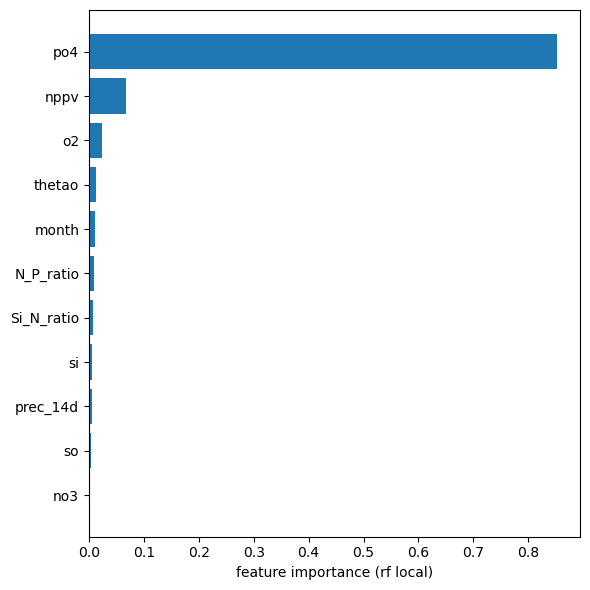

In [12]:
import matplotlib.pyplot as plt

importances_rf_local = rf_local.feature_importances_
indices_rf_local = np.argsort(importances_rf_local)[::-1]
sorted_features_rf_local = [feature_cols_local[i] for i in indices_rf_local]

for f, imp in zip(sorted_features_rf_local, importances_rf_local[indices_rf_local]):
    print(f, imp)

plt.figure(figsize=(6, 6))
plt.barh(range(len(sorted_features_rf_local)), importances_rf_local[indices_rf_local])
plt.yticks(range(len(sorted_features_rf_local)), sorted_features_rf_local)
plt.gca().invert_yaxis()
plt.xlabel("feature importance (rf local)")
plt.tight_layout()
plt.show()


In [13]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

xgb_local = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_local.fit(X_train_local, y_train)

y_pred_train_xgb_local = xgb_local.predict(X_train_local)
y_pred_test_xgb_local = xgb_local.predict(X_test_local)

r2_train_xgb_local = r2_score(y_train, y_pred_train_xgb_local)
r2_test_xgb_local = r2_score(y_test, y_pred_test_xgb_local)
rmse_train_xgb_local = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb_local))
rmse_test_xgb_local = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb_local))

print("Train R2 (xgb local):", r2_train_xgb_local)
print("Test R2 (xgb local):", r2_test_xgb_local)
print("Train RMSE (xgb local):", rmse_train_xgb_local)
print("Test RMSE (xgb local):", rmse_test_xgb_local)


Train R2 (xgb local): 0.9894170205529003
Test R2 (xgb local): 0.9393590049661562
Train RMSE (xgb local): 0.030720849833506616
Test RMSE (xgb local): 0.06511813909645361


po4 0.68691784
thetao 0.13757336
nppv 0.050428856
N_P_ratio 0.03931886
o2 0.033599533
month 0.02004465
Si_N_ratio 0.008223752
si 0.007295911
no3 0.006542126
so 0.0058516124
prec_14d 0.004203531


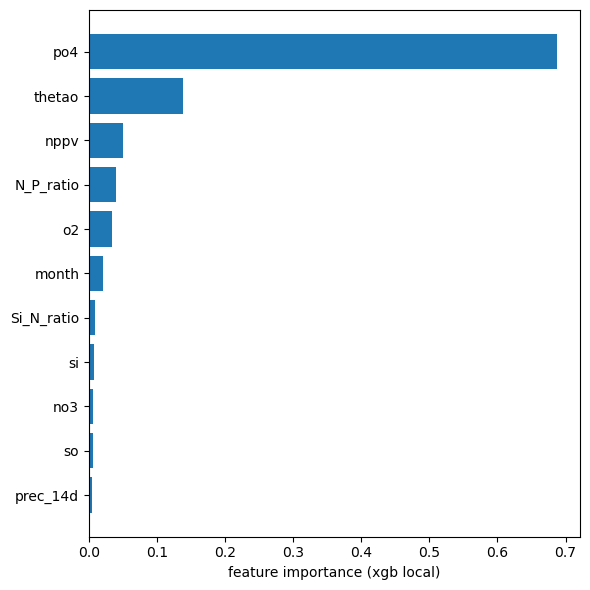

In [14]:
importances_xgb_local = xgb_local.feature_importances_
indices_xgb_local = np.argsort(importances_xgb_local)[::-1]
sorted_features_xgb_local = [feature_cols_local[i] for i in indices_xgb_local]

for f, imp in zip(sorted_features_xgb_local, importances_xgb_local[indices_xgb_local]):
    print(f, imp)

plt.figure(figsize=(6, 6))
plt.barh(range(len(sorted_features_xgb_local)), importances_xgb_local[indices_xgb_local])
plt.yticks(range(len(sorted_features_xgb_local)), sorted_features_xgb_local)
plt.gca().invert_yaxis()
plt.xlabel("feature importance (xgb local)")
plt.tight_layout()
plt.show()


In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import numpy as np

param_dist_xgb_local = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.1, 1.0, 10.0],
    "reg_alpha": [0.0, 0.1, 1.0],
}

xgb_base_local = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_random_local = RandomizedSearchCV(
    estimator=xgb_base_local,
    param_distributions=param_dist_xgb_local,
    n_iter=20,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring="r2",
)

xgb_random_local.fit(X_train_local, y_train)

print("Best params (xgb local):", xgb_random_local.best_params_)
print("Best CV score (xgb local):", xgb_random_local.best_score_)

xgb_best_local = xgb_random_local.best_estimator_

y_pred_train_xgb_best_local = xgb_best_local.predict(X_train_local)
y_pred_test_xgb_best_local = xgb_best_local.predict(X_test_local)

r2_train_xgb_best_local = r2_score(y_train, y_pred_train_xgb_best_local)
r2_test_xgb_best_local = r2_score(y_test, y_pred_test_xgb_best_local)
rmse_train_xgb_best_local = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb_best_local))
rmse_test_xgb_best_local = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb_best_local))

print("Train R2 (xgb local best):", r2_train_xgb_best_local)
print("Test R2 (xgb local best):", r2_test_xgb_best_local)
print("Train RMSE (xgb local best):", rmse_train_xgb_best_local)
print("Test RMSE (xgb local best):", rmse_test_xgb_best_local)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params (xgb local): {'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV score (xgb local): 0.9306300795900596
Train R2 (xgb local best): 0.9955905304372263
Test R2 (xgb local best): 0.9391599489251423
Train RMSE (xgb local best): 0.019829986734374683
Test RMSE (xgb local best): 0.06522492774005172


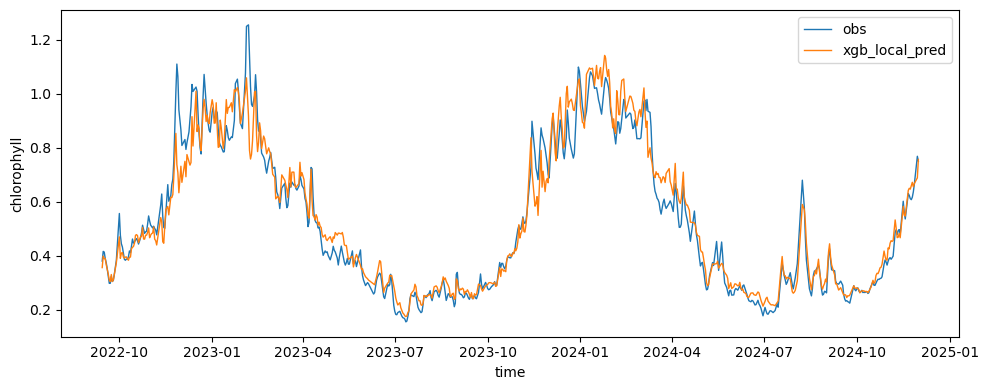

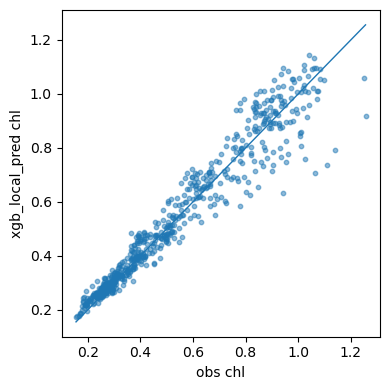

In [16]:
time_index = df_spatial.index
time_test = time_index[train_size:]

y_pred_test_xgb_best = xgb_best_local.predict(X_test_local)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(time_test, y_test, label="obs", linewidth=1)
plt.plot(time_test, y_pred_test_xgb_best, label="xgb_local_pred", linewidth=1)
plt.xlabel("time")
plt.ylabel("chlorophyll")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred_test_xgb_best, s=10, alpha=0.5)
lims = [min(y_test.min(), y_pred_test_xgb_best.min()), max(y_test.max(), y_pred_test_xgb_best.max())]
plt.plot(lims, lims, linewidth=1)
plt.xlabel("obs chl")
plt.ylabel("xgb_local_pred chl")
plt.tight_layout()
plt.show()


po4 0.69487953
thetao 0.12880373
nppv 0.04843507
o2 0.035015438
N_P_ratio 0.032651033
month 0.025817337
Si_N_ratio 0.009619666
si 0.0074709044
no3 0.0060136677
so 0.0056853695
prec_14d 0.005608203


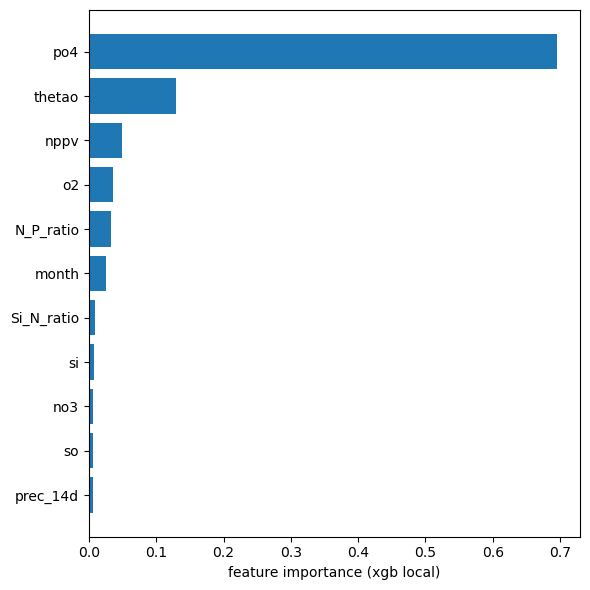

In [17]:
importances_xgb_local = xgb_best_local.feature_importances_
indices_xgb_local = np.argsort(importances_xgb_local)[::-1]
sorted_features_xgb_local = [feature_cols_local[i] for i in indices_xgb_local]

for f, imp in zip(sorted_features_xgb_local, importances_xgb_local[indices_xgb_local]):
    print(f, imp)

plt.figure(figsize=(6, 6))
plt.barh(range(len(sorted_features_xgb_local)), importances_xgb_local[indices_xgb_local])
plt.yticks(range(len(sorted_features_xgb_local)), sorted_features_xgb_local)
plt.gca().invert_yaxis()
plt.xlabel("feature importance (xgb local)")
plt.tight_layout()
plt.show()


In [18]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

feature_cols_local = [
    "prec_14d",
    "month",
    "thetao",
    "so",
    "no3",
    "po4",
    "si",
    "o2",
    "nppv",
    "N_P_ratio",
    "Si_N_ratio",
]

X_all_local_df = df_spatial[feature_cols_local].copy()
y_all_df = df_spatial[["chl"]].copy()

n_total = len(df_spatial)
train_size = int(n_total * 0.8)

X_train_df = X_all_local_df.iloc[:train_size].copy()
X_test_df = X_all_local_df.iloc[train_size:].copy()
y_train_df = y_all_df.iloc[:train_size].copy()
y_test_df = y_all_df.iloc[train_size:].copy()

mean_local = X_train_df.mean()
std_local = X_train_df.std()

X_train_df = (X_train_df - mean_local) / std_local
X_test_df = (X_test_df - mean_local) / std_local

X_train_arr = X_train_df.to_numpy()
X_test_arr = X_test_df.to_numpy()
y_train_arr = y_train_df.to_numpy().ravel()
y_test_arr = y_test_df.to_numpy().ravel()

def create_sequences(X, y, slider):
    X_seq = []
    y_seq = []
    for i in range(slider, len(X)):
        X_seq.append(X[i-slider:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

slider = 14

X_train_seq, y_train_seq = create_sequences(X_train_arr, y_train_arr, slider)
X_test_seq, y_test_seq = create_sequences(X_test_arr, y_test_arr, slider)

print(X_train_seq.shape, y_train_seq.shape, X_test_seq.shape, y_test_seq.shape)


(2557, 14, 11) (2557,) (629, 14, 11) (629,)


In [19]:
train_dataset_full = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_train_seq),
    torch.FloatTensor(y_train_seq.reshape(-1, 1))
)

test_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_test_seq),
    torch.FloatTensor(y_test_seq.reshape(-1, 1))
)

train_size_ds = int(0.8 * len(train_dataset_full))
val_size_ds = len(train_dataset_full) - train_size_ds
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset_full,
    [train_size_ds, val_size_ds]
)

minibatch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=minibatch_size,
    shuffle=False
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=minibatch_size,
    shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=minibatch_size,
    shuffle=False
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [20]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, activation="ReLU", num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            getattr(nn, activation)(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        x = out[:, -1, :]
        x = self.fc(x)
        return x

n_neuron = 64
activation = "ReLU"

model = LSTMModel(
    input_size=X_train_seq.shape[2],
    hidden_size=n_neuron,
    output_size=1,
    activation=activation,
    num_layers=2
)

learning_rate = 0.001
num_epochs = 80

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

model.to(device)


LSTMModel(
  (lstm): LSTM(11, 64, num_layers=2, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [22]:
import torch.nn as nn

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 80

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss_epoch = 0.0
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss_epoch += loss.item() * batch_X.size(0)
    train_loss_epoch /= len(train_loader.dataset)
    train_losses.append(train_loss_epoch)

    model.eval()
    val_loss_epoch = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss_epoch += loss.item() * batch_X.size(0)
    val_loss_epoch /= len(val_loader.dataset)
    val_losses.append(val_loss_epoch)

    print(f"Epoch {epoch+1:03d} | train_loss={train_loss_epoch:.4f} | val_loss={val_loss_epoch:.4f}")


Epoch 001 | train_loss=0.1243 | val_loss=0.0175
Epoch 002 | train_loss=0.0101 | val_loss=0.0071
Epoch 003 | train_loss=0.0065 | val_loss=0.0055
Epoch 004 | train_loss=0.0058 | val_loss=0.0050
Epoch 005 | train_loss=0.0053 | val_loss=0.0046
Epoch 006 | train_loss=0.0049 | val_loss=0.0044
Epoch 007 | train_loss=0.0045 | val_loss=0.0041
Epoch 008 | train_loss=0.0042 | val_loss=0.0039
Epoch 009 | train_loss=0.0039 | val_loss=0.0037
Epoch 010 | train_loss=0.0037 | val_loss=0.0036
Epoch 011 | train_loss=0.0036 | val_loss=0.0035
Epoch 012 | train_loss=0.0034 | val_loss=0.0034
Epoch 013 | train_loss=0.0033 | val_loss=0.0033
Epoch 014 | train_loss=0.0032 | val_loss=0.0032
Epoch 015 | train_loss=0.0032 | val_loss=0.0032
Epoch 016 | train_loss=0.0031 | val_loss=0.0031
Epoch 017 | train_loss=0.0030 | val_loss=0.0031
Epoch 018 | train_loss=0.0029 | val_loss=0.0030
Epoch 019 | train_loss=0.0029 | val_loss=0.0029
Epoch 020 | train_loss=0.0028 | val_loss=0.0029
Epoch 021 | train_loss=0.0028 | val_loss

In [23]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

model.eval()
y_pred_list = []
y_true_list = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X).cpu().numpy().ravel()
        y_pred_list.append(outputs)
        y_true_list.append(batch_y.numpy().ravel())

y_pred_lstm = np.concatenate(y_pred_list)
y_true_lstm = np.concatenate(y_true_list)

r2_test_lstm = r2_score(y_true_lstm, y_pred_lstm)
rmse_test_lstm = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))

print("Test R2 (lstm local):", r2_test_lstm)
print("Test RMSE (lstm local):", rmse_test_lstm)


Test R2 (lstm local): 0.9315048456192017
Test RMSE (lstm local): 0.06963500147353123


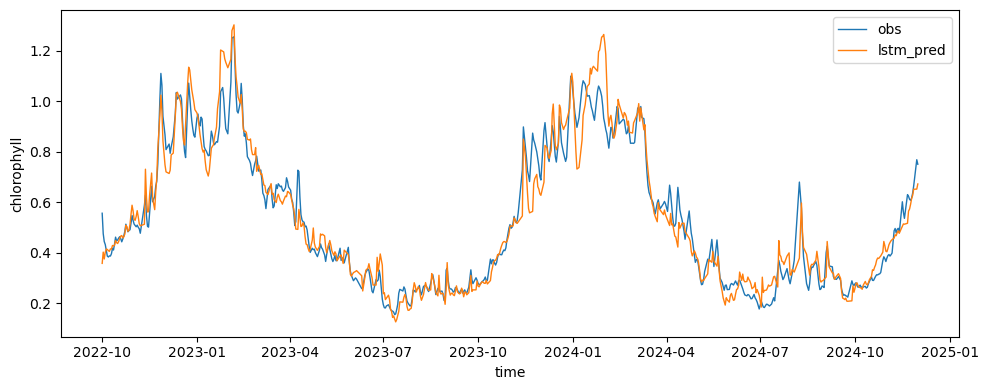

In [24]:
time_index = df_spatial.index
time_test_full = time_index[train_size:]
time_test_lstm = time_test_full[slider:]

plt.figure(figsize=(10, 4))
plt.plot(time_test_lstm, y_true_lstm, label="obs", linewidth=1)
plt.plot(time_test_lstm, y_pred_lstm, label="lstm_pred", linewidth=1)
plt.xlabel("time")
plt.ylabel("chlorophyll")
plt.legend()
plt.tight_layout()
plt.show()


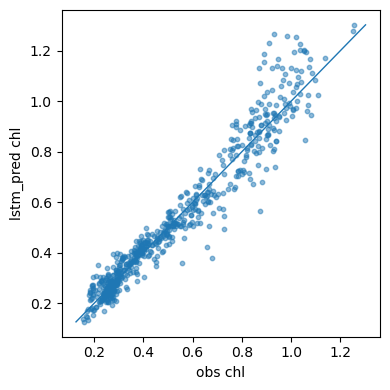

In [25]:
plt.figure(figsize=(4, 4))
plt.scatter(y_true_lstm, y_pred_lstm, s=10, alpha=0.5)
lims = [min(y_true_lstm.min(), y_pred_lstm.min()), max(y_true_lstm.max(), y_pred_lstm.max())]
plt.plot(lims, lims, linewidth=1)
plt.xlabel("obs chl")
plt.ylabel("lstm_pred chl")
plt.tight_layout()
plt.show()


In [34]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score, mean_squared_error

feature_cols_local = [
    "prec_14d",
    "month",
    "thetao",
    "so",
    "no3",
    "po4",
    "si",
    "o2",
    "nppv",
    "N_P_ratio",
    "Si_N_ratio",
]

X_all_df_nn = df_spatial[feature_cols_local].copy()
y_all_df_nn = df_spatial[["chl"]].copy()

n_total_nn = len(df_spatial)
train_size_time_nn = int(0.8 * n_total_nn)

X_train_df_nn = X_all_df_nn.iloc[:train_size_time_nn].copy()
X_test_df_nn = X_all_df_nn.iloc[train_size_time_nn:].copy()
y_train_df_nn = y_all_df_nn.iloc[:train_size_time_nn].copy()
y_test_df_nn = y_all_df_nn.iloc[train_size_time_nn:].copy()

mean_nn = X_train_df_nn.mean()
std_nn = X_train_df_nn.std()

X_train_df_nn = (X_train_df_nn - mean_nn) / std_nn
X_test_df_nn = (X_test_df_nn - mean_nn) / std_nn

X_train_nn = X_train_df_nn.to_numpy()
y_train_nn = y_train_df_nn.to_numpy()
X_test_nn = X_test_df_nn.to_numpy()
y_test_nn = y_test_df_nn.to_numpy()


In [35]:
train_dataset_full_nn = TensorDataset(
    torch.FloatTensor(X_train_nn),
    torch.FloatTensor(y_train_nn)
)

test_dataset_nn = TensorDataset(
    torch.FloatTensor(X_test_nn),
    torch.FloatTensor(y_test_nn)
)

train_size_ds_nn = int(0.8 * len(train_dataset_full_nn))
val_size_ds_nn = len(train_dataset_full_nn) - train_size_ds_nn
train_dataset_nn, val_dataset_nn = torch.utils.data.random_split(
    train_dataset_full_nn,
    [train_size_ds_nn, val_size_ds_nn]
)

minibatch_size = 64

train_loader_nn = DataLoader(
    train_dataset_nn,
    batch_size=minibatch_size,
    shuffle=True
)
val_loader_nn = DataLoader(
    val_dataset_nn,
    batch_size=minibatch_size,
    shuffle=False
)
test_loader_nn = DataLoader(
    test_dataset_nn,
    batch_size=minibatch_size,
    shuffle=False
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [36]:
n_neuron = 64
activation = "ReLU"
num_epochs = 80
learning_rate = 0.001
N_layers = 2

layers = []
layers.append(nn.Linear(X_train_nn.shape[1], n_neuron))
layers.append(getattr(nn, activation)())

for n in range(N_layers - 1):
    layers.append(nn.Linear(n_neuron, n_neuron))
    layers.append(getattr(nn, activation)())

layers.append(nn.Linear(n_neuron, y_train_nn.shape[1]))

model_nn = nn.Sequential(*layers)
model_nn.to(device)

optimizer_nn = torch.optim.Adam(model_nn.parameters(), lr=learning_rate)
criterion_nn = nn.MSELoss()


In [37]:
best_val_loss_nn = float("inf")
patience_nn = 20
patience_counter_nn = 0

train_losses_nn = []
val_losses_nn = []

for epoch in range(num_epochs):
    model_nn.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader_nn:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        optimizer_nn.zero_grad()
        outputs = model_nn(batch_X)
        loss = criterion_nn(outputs, batch_y)
        loss.backward()
        optimizer_nn.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_nn)

    model_nn.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader_nn:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model_nn(batch_X)
            loss = criterion_nn(outputs, batch_y)
            val_loss += loss.item()
    val_loss /= len(val_loader_nn)

    train_losses_nn.append(train_loss)
    val_losses_nn.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss_nn:
        best_val_loss_nn = val_loss
        patience_counter_nn = 0
    else:
        patience_counter_nn += 1
        if patience_counter_nn >= patience_nn:
            print(f"Early stopping at epoch {epoch+1}")
            break


Epoch 1/80, Train Loss: 0.0860, Val Loss: 0.0263
Epoch 2/80, Train Loss: 0.0115, Val Loss: 0.0138
Epoch 3/80, Train Loss: 0.0080, Val Loss: 0.0102
Epoch 4/80, Train Loss: 0.0062, Val Loss: 0.0087
Epoch 5/80, Train Loss: 0.0056, Val Loss: 0.0078
Epoch 6/80, Train Loss: 0.0051, Val Loss: 0.0071
Epoch 7/80, Train Loss: 0.0047, Val Loss: 0.0065
Epoch 8/80, Train Loss: 0.0046, Val Loss: 0.0061
Epoch 9/80, Train Loss: 0.0046, Val Loss: 0.0054
Epoch 10/80, Train Loss: 0.0039, Val Loss: 0.0052
Epoch 11/80, Train Loss: 0.0037, Val Loss: 0.0049
Epoch 12/80, Train Loss: 0.0034, Val Loss: 0.0046
Epoch 13/80, Train Loss: 0.0033, Val Loss: 0.0043
Epoch 14/80, Train Loss: 0.0032, Val Loss: 0.0043
Epoch 15/80, Train Loss: 0.0031, Val Loss: 0.0042
Epoch 16/80, Train Loss: 0.0032, Val Loss: 0.0044
Epoch 17/80, Train Loss: 0.0031, Val Loss: 0.0044
Epoch 18/80, Train Loss: 0.0030, Val Loss: 0.0041
Epoch 19/80, Train Loss: 0.0029, Val Loss: 0.0041
Epoch 20/80, Train Loss: 0.0029, Val Loss: 0.0040
Epoch 21/

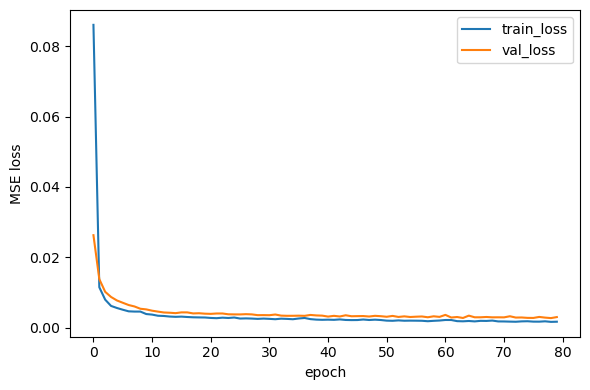

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(train_losses_nn, label="train_loss")
plt.plot(val_losses_nn, label="val_loss")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
plt.show()


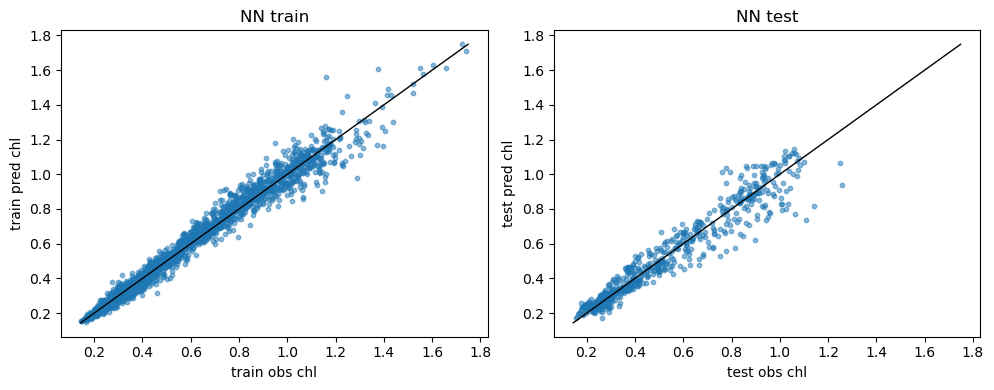

In [39]:
model_nn.eval()

with torch.no_grad():
    y_train_pred_nn_full = model_nn(torch.FloatTensor(X_train_nn).to(device)).cpu().numpy().ravel()
    y_test_pred_nn_full = model_nn(torch.FloatTensor(X_test_nn).to(device)).cpu().numpy().ravel()

y_train_true_nn_full = y_train_nn.ravel()
y_test_true_nn_full = y_test_nn.ravel()

min_val = min(y_train_true_nn_full.min(), y_test_true_nn_full.min(), 
              y_train_pred_nn_full.min(), y_test_pred_nn_full.min())
max_val = max(y_train_true_nn_full.max(), y_test_true_nn_full.max(), 
              y_train_pred_nn_full.max(), y_test_pred_nn_full.max())
lims = [min_val, max_val]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_train_true_nn_full, y_train_pred_nn_full, s=10, alpha=0.5)
plt.plot(lims, lims, "k-", linewidth=1)
plt.xlabel("train obs chl")
plt.ylabel("train pred chl")
plt.title("NN train")

plt.subplot(1, 2, 2)
plt.scatter(y_test_true_nn_full, y_test_pred_nn_full, s=10, alpha=0.5)
plt.plot(lims, lims, "k-", linewidth=1)
plt.xlabel("test obs chl")
plt.ylabel("test pred chl")
plt.title("NN test")

plt.tight_layout()
plt.show()


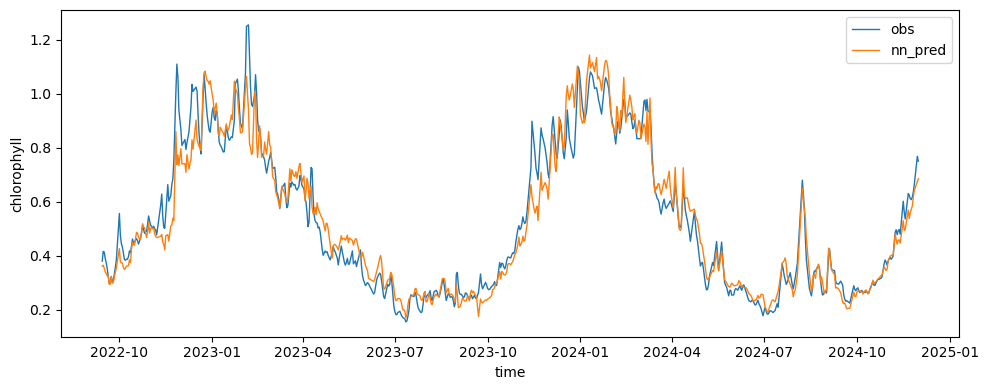

In [40]:
time_index_nn = df_spatial.index
time_train_nn = time_index_nn[:train_size_time_nn]
time_test_nn = time_index_nn[train_size_time_nn:]

plt.figure(figsize=(10, 4))
plt.plot(time_test_nn, y_test_true_nn_full, label="obs", linewidth=1)
plt.plot(time_test_nn, y_test_pred_nn_full, label="nn_pred", linewidth=1)
plt.xlabel("time")
plt.ylabel("chlorophyll")
plt.legend()
plt.tight_layout()
plt.show()
